# Group 03 — Speech and silence segmentation

**Student: Vương Quốc Trung**  
**Assigned algorithm: Histogram**

This notebook contains the source code and saved execution outputs. Viewing the results does not require WAV files. To rerun it, supply the original datasets separately and update DATA_ROOT. Do not include WAV/LAB files in the submission.

Analysis window: 25 ms. Decision hop: 10 ms. Minimum Silence duration: 200 ms. TRAIN LAB labels support calibration following BT1; TEST LAB labels are used only for evaluation and reference-boundary plots.

## 1. Libraries and configuration

Signal processing uses NumPy and the Python standard library. Matplotlib and IPython display and save figure outputs in this notebook.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict, replace
from pathlib import Path
import json
import math
import wave

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Display PNGs inline and save notebook outputs without opening GUI windows.
get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("png")
FRAME_MS, HOP_MS, MIN_SILENCE_MS = 25, 10, 200
FEATURE_LAYOUT, TRAINING_PROTOCOL = "centered_hop_v1", "train_calibration"
MEDIAN_ORDERS = (1, 5, 9, 11, 15, 21)
HISTOGRAM_WEIGHTS = (1, 2, 5, 10, 15, 20, 30, 50)
METHOD, STUDENT = 'histogram', 'Vương Quốc Trung'
METHOD_LABELS = {METHOD: 'Histogram'}

# Execute with the kernel working directory at the root containing the datasets.
# On another machine, set DATA_ROOT to the original WAV/LAB dataset location.
DATA_ROOT = Path.cwd()


## 2. Reading WAV/LAB files and assigning frame labels

Match WAV and LAB files by their base names. The sil label means Silence; both v and uv mean Speech. Assign labels at decision-cell centers and exclude time points outside the labeled range.

In [2]:
@dataclass(frozen=True)
class Interval:
    """A labeled time interval from a LAB file.

    Attributes:
        start: Segment start time in seconds.
        end: Segment end time in seconds.
        speech: True for Speech (v or uv), False for Silence (sil).
    """
    start: float
    end: float
    speech: bool


@dataclass(frozen=True)
class Record:
    """A complete audio recording with reference labels.

    Attributes:
        name: Recording name, such as phone_F2 or studio_M1.
        fs: WAV sampling rate in Hz.
        samples: One-dimensional float samples normalized to [-1, 1].
        labels: Tuple of reference intervals read from the LAB file.
        reference_f0_mean: Optional LAB F0mean statistic.
        reference_f0_std: Optional LAB F0std statistic.
    """
    name: str
    fs: int
    samples: np.ndarray
    labels: tuple[Interval, ...]
    reference_f0_mean: float | None = None
    reference_f0_std: float | None = None

    @property
    def duration(self) -> float:
        """Total recording duration in seconds."""
        return len(self.samples) / self.fs


def discover(root: Path, split: str) -> list[Path]:
    """Recursively locate the WAV/LAB dataset folder for the requested split.

    Args:
        root: Root directory to search.
        split: Dataset folder name, such as TinHieuHuanLuyen or TinHieuKiemThu.

    Returns:
        WAV file paths sorted alphabetically.
    """
    # Block 1: Locate the requested dataset folder in the directory tree.
    folders = [p for p in root.rglob(split) if p.is_dir()]
    if len(folders) != 1:
        raise ValueError(f"Expected exactly one dataset folder {split}, found {len(folders)}")

    # Block 2: List WAV files and check their matching LAB files.
    target_folder = folders[0]
    wav_files = sorted(target_folder.glob("*.wav"))
    lab_names = {p.stem for p in target_folder.glob("*.lab")}

    # Block 3: Require a corresponding LAB file for every WAV.
    if not wav_files or {p.stem for p in wav_files} != lab_names:
        raise ValueError(f"WAV/LAB pairs do not match in {target_folder}")

    return wav_files


def read_labels(path: Path, duration: float) -> tuple[Interval, ...]:
    """Read and validate segmentation labels from a LAB file.

    Each data row contains start time, end time and a label.
    The sil label means Silence; both v (voiced) and uv (unvoiced) mean Speech.

    Args:
        path: LAB file path.
        duration: Corresponding WAV duration in seconds for coverage validation.

    Returns:
        Tuple of valid, continuous Interval objects.
    """
    # Block 1: Read the text and retain valid label data rows.
    intervals: list[Interval] = []
    lines = path.read_text(encoding="utf-8").splitlines()

    for line_num, line in enumerate(lines, 1):
        fields = line.split()
        # Skip blank lines and rows containing F0 statistics.
        if not fields or fields[0] in {"F0mean", "F0std"}:
            continue

        if len(fields) != 3 or fields[2] not in {"sil", "v", "uv"}:
            raise ValueError(f"Invalid label format at {path}:{line_num}")

        # Block 2: Parse and validate interval start/end times.
        try:
            start_time, end_time = float(fields[0]), float(fields[1])
        except ValueError as exc:
            raise ValueError(f"Invalid time value at {path}:{line_num}") from exc

        if start_time < 0 or end_time <= start_time or (intervals and abs(start_time - intervals[-1].end) > 1e-6):
            raise ValueError(f"Discontinuous or overlapping label intervals at {path}:{line_num}")

        # Map v and uv to Speech (True), and sil to Silence (False).
        intervals.append(Interval(start_time, end_time, fields[2] != "sil"))

    # Block 3: Check LAB coverage against the WAV duration.
    if not intervals or abs(intervals[0].start) > 1e-6 or intervals[-1].end > duration + 0.011:
        raise ValueError(f"LAB time coverage does not match WAV duration: {path}")

    return tuple(intervals)


def read_record(path: Path) -> Record:
    """Read WAV samples, reference labels and optional F0 statistics.

    Use the Python wave module to read 16-bit PCM data and convert it to
    floating-point samples in [-1, 1]. For stereo audio, use the first channel.

    Args:
        path: WAV file path.

    Returns:
        Record containing the waveform, reference labels and F0 statistics.
    """
    # Block 1: Read WAV data with the Python standard-library wave module.
    with wave.open(str(path), "rb") as wave_file:
        fs = wave_file.getframerate()
        n_channels = wave_file.getnchannels()
        samp_width = wave_file.getsampwidth()
        n_frames = wave_file.getnframes()
        raw_bytes = wave_file.readframes(n_frames)

    # Block 2: Validate 16-bit PCM format and channel count.
    if samp_width != 2:
        raise ValueError(f"Only 16-bit PCM audio is supported: {path}")

    raw_samples = np.frombuffer(raw_bytes, dtype=np.int16)
    if n_channels == 2:
        # For stereo recordings, use the first channel.
        raw_samples = raw_samples[::2]
    elif n_channels > 2:
        raise ValueError(f"Audio with more than two channels is unsupported: {path}")

    # Normalize sample amplitudes to [-1, 1].
    samples = raw_samples.astype(np.float64) / 32768.0

    # Block 3: Load LAB intervals and optional F0mean/F0std statistics.
    lab_path = path.with_suffix(".lab")
    f0_stats: dict[str, float] = {}
    if lab_path.exists():
        for line in lab_path.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) == 2 and parts[0] in {"F0mean", "F0std"}:
                f0_stats[parts[0]] = float(parts[1])

    labels = read_labels(lab_path, len(samples) / fs)

    return Record(
        name=path.stem,
        fs=fs,
        samples=samples,
        labels=labels,
        reference_f0_mean=f0_stats.get("F0mean"),
        reference_f0_std=f0_stats.get("F0std")
    )


def speech_at(times: np.ndarray, labels: tuple[Interval, ...]) -> tuple[np.ndarray, np.ndarray]:
    """Assign Speech/Silence reference labels at frame decision centers.

    Args:
        times: One-dimensional array of decision-center times in seconds.
        labels: Tuple of reference LAB intervals.

    Returns:
        Tuple of is_speech (True for Speech) and is_valid (within labeled data).
    """
    # Block 1: Initialize the boolean result arrays.
    is_speech = np.zeros(len(times), dtype=bool)
    is_valid = np.zeros(len(times), dtype=bool)

    # Block 2: Project labeled intervals onto decision-center times.
    for segment in labels:
        in_segment = (times >= segment.start) & (times < segment.end)
        is_valid |= in_segment
        is_speech[in_segment] = segment.speech

    return is_speech, is_valid


def reference_boundaries(labels: tuple[Interval, ...]) -> list[tuple[float, bool]]:
    """Extract reference transition boundaries from the labeled intervals.

    Args:
        labels: Tuple of reference intervals.

    Returns:
        List of (boundary_time_s, starts_speech) pairs.
    """
    # Block 1: Compare adjacent intervals to find class transitions.
    ground_truth_boundaries = [
        (current.start, current.speech)
        for prev, current in zip(labels, labels[1:])
        if current.speech != prev.speech
    ]
    return ground_truth_boundaries

## 3. Short-time features, F0 and post-processing

Compute STE and MA directly from the samples. Use 25 ms analysis windows centered on 10 ms decision cells, with the first center at 5 ms. At WAV edges, use actual samples without zero padding. Normalize STE by the maximum of each recording. Estimate F0 with autocorrelation for illustration; it does not determine the segmentation threshold. Fill Silence intervals shorter than 200 ms with Speech. All-zero audio remains Silence.

In [3]:
@dataclass(frozen=True)
class Features:
    """Short-time features extracted from an audio recording.

    Attributes:
        times: Frame decision-center times in seconds.
        ste: Unnormalized short-time energy.
        ma: Short-time mean absolute magnitude.
        normalized_ste: STE normalized to [0, 1] by the recording maximum.
        log_ste: Energy levels on a logarithmic scale in dB.
        log_ma: Magnitude levels on a logarithmic scale in dB.
        f0: Estimated fundamental frequency in Hz, or NaN if rejected.
        edges: Start and end times of decision cells in seconds.
        decision_ste: Features used for thresholding; Binary uses median-filtered
            normalized STE without renormalizing the filtered result.
    """
    times: np.ndarray
    ste: np.ndarray
    ma: np.ndarray
    normalized_ste: np.ndarray
    log_ste: np.ndarray
    log_ma: np.ndarray
    f0: np.ndarray
    edges: np.ndarray
    decision_ste: np.ndarray | None = None


def extract(samples: np.ndarray, fs: int, frame_ms: int, hop_ms: int = HOP_MS,
            compute_f0: bool = True) -> Features:
    """Extract short-time features from WAV samples.

    Form overlapping analysis windows, compute STE, MA, logSTE and logMA,
    normalize STE by its maximum, and estimate F0 when requested.

    Args:
        samples: One-dimensional float audio samples in [-1, 1].
        fs: Sampling rate in Hz, such as 16000 or 44100.
        frame_ms: Window length in ms; the assignment always passes 25.
        hop_ms: Decision hop in ms, default 10.
        compute_f0: Whether to estimate F0, default True.

    Returns:
        Features containing all computed feature arrays.
    """
    # Block 1: Convert the window and hop durations from ms to samples.
    frame_len = max(1, round(fs * frame_ms / 1000))
    hop_len = max(1, round(fs * hop_ms / 1000))
    if len(samples) == 0:
        raise ValueError("Cannot extract features from an empty WAV signal")

    # Block 2: Each decision cell spans one hop; center the analysis window on it.
    # The nominal window is 25 ms; edge windows use only actual WAV samples.
    starts = np.arange(0, len(samples), hop_len)
    edges = np.r_[starts / fs, len(samples) / fs]
    times = (edges[:-1] + edges[1:]) / 2
    frames = []
    for time in times:
        left = round((time - frame_ms / 2000) * fs)
        frames.append(samples[max(0, left):min(len(samples), left + frame_len)])

    # Block 3: Compute short-time energy (STE) and mean magnitude (MA).
    # STE = mean(x^2), MA = mean(abs(x)); divide by the actual window sample count.
    ste = np.asarray([np.mean(frame * frame) for frame in frames])
    ma = np.asarray([np.mean(np.abs(frame)) for frame in frames])

    # Block 4: Normalize STE to [0, 1] by the recording maximum.
    max_ste = float(np.max(ste))
    normalized_ste = ste / max_ste if max_ste > 0 else np.zeros_like(ste)

    # Block 5: Estimate F0 and compute logarithmic features in dB.
    f0 = estimate_f0(frames, fs, normalized_ste) if compute_f0 else np.full(len(frames), np.nan)
    log_ste = 10 * np.log10(np.maximum(ste, 1e-12))
    log_ma = 20 * np.log10(np.maximum(ma, 1e-12))

    # Block 6: Threshold normalized STE by default; Binary uses its median-filtered version.
    return Features(times, ste, ma, normalized_ste, log_ste, log_ma, f0, edges, normalized_ste)


def estimate_f0(frames: list[np.ndarray] | np.ndarray, fs: int, normalized_ste: np.ndarray,
                minimum_hz: float = 60.0, maximum_hz: float = 400.0) -> np.ndarray:
    """Estimate F0 using short-time autocorrelation.

    Require sufficient frame energy and an accepted correlation peak.
    Frames that fail these checks receive NaN.

    Args:
        frames: Actual-sample windows; edge windows may be shorter.
        fs: Sampling rate in Hz.
        normalized_ste: Normalized energy for each frame.
        minimum_hz: Lower F0 bound in Hz, default 60.
        maximum_hz: Upper F0 bound in Hz, default 400.

    Returns:
        One-dimensional F0 array in Hz, with NaN for rejected estimates.
    """
    # Block 1: Set the lag search range from the F0 frequency bounds.
    min_lag = max(1, int(fs / maximum_hz))
    result = np.full(len(frames), np.nan)

    # Block 2: Process each analysis window for autocorrelation.
    for index, frame in enumerate(frames):
        # Skip windows with insufficient energy.
        max_lag = min(len(frame) - 1, int(fs / minimum_hz))
        if normalized_ste[index] < 0.01 or max_lag < min_lag:
            continue

        # Remove DC and apply a Hamming window to reduce spectral leakage.
        centered = (frame - np.mean(frame)) * np.hamming(len(frame))

        # Block 3: Compute short-time autocorrelation using FFT and IFFT.
        fft_size = 1 << (2 * len(centered) - 1).bit_length()
        spectrum = np.fft.rfft(centered, n=fft_size)
        correlation = np.fft.irfft(spectrum * np.conj(spectrum), n=fft_size)[:len(centered)]

        # Block 4: Find the strongest peak within [min_lag, max_lag].
        if correlation[0] <= 1e-12:
            continue
        search_region = correlation[min_lag:max_lag + 1]
        best_lag = min_lag + int(np.argmax(search_region))

        # Block 5: Accept the F0 estimate only if normalized correlation is at least 0.30.
        if correlation[best_lag] / correlation[0] >= 0.30:
            result[index] = fs / best_lag

    return result


def median_filter(values: np.ndarray, order: int) -> np.ndarray:
    """Return a sliding median for STE and a positive odd order, replicating edges without renormalizing."""
    # Block 1: Order one preserves the input; require a nonempty input and odd order.
    if order < 1 or order % 2 == 0 or not len(values):
        raise ValueError("Median filtering requires a positive odd order and a nonempty input")
    if order == 1:
        return values.copy()
    radius = order // 2
    padded = np.pad(values, radius, mode="edge")

    # Block 2: Visit windows explicitly and compute their medians with basic NumPy operations.
    filtered = np.empty(len(values), dtype=float)
    for index in range(len(values)):
        filtered[index] = np.median(padded[index:index + order])
    return filtered


def remove_virtual_silence(mask: np.ndarray, edges: np.ndarray, minimum_s: float = 0.2) -> np.ndarray:
    """Fill Silence intervals shorter than the minimum duration, normally 200 ms.

    Convert a predicted Silence interval below the duration limit to Speech.

    Args:
        mask: Initial frame classification; True means Speech.
        edges: Decision-cell boundary times in seconds.
        minimum_s: Minimum Silence duration in seconds, default 0.2.

    Returns:
        New boolean mask after filling all shorter Silence intervals.
    """
    # Block 1: Copy the mask and locate Silence-state transitions.
    cleaned_mask = mask.copy()
    is_silence = ~cleaned_mask
    change_indices = np.flatnonzero(np.diff(np.r_[False, is_silence, False]))

    # Block 2: Visit continuous Silence intervals and measure their actual duration.
    for start_idx, end_idx in change_indices.reshape(-1, 2):
        duration = edges[end_idx] - edges[start_idx]
        # Convert a Silence interval shorter than 200 ms to Speech (True).
        if duration < minimum_s - 1e-12:
            cleaned_mask[start_idx:end_idx] = True

    return cleaned_mask


def segments(mask: np.ndarray, edges: np.ndarray) -> list[tuple[float, float, bool]]:
    """Convert a classification mask into continuous time segments.

    Args:
        mask: Frame classification; True means Speech.
        edges: Decision-cell boundary times in seconds.

    Returns:
        List of (start_time_s, end_time_s, is_speech) tuples.
    """
    # Block 1: Find class changes between adjacent decision cells.
    change_points = np.r_[0, np.flatnonzero(np.diff(mask)) + 1, len(mask)]

    # Block 2: Build the corresponding start/end time intervals.
    segment_list = [
        (float(edges[start]), float(edges[end]), bool(mask[start]))
        for start, end in zip(change_points, change_points[1:])
    ]
    return segment_list


def predicted_boundaries(mask: np.ndarray, edges: np.ndarray) -> list[tuple[float, bool]]:
    """Extract predicted transitions between Speech and Silence.

    Args:
        mask: Frame classification mask.
        edges: Decision-cell boundary times in seconds.

    Returns:
        List of (boundary_time_s, starts_speech) pairs.
    """
    # Block 1: Locate transitions from 0 to 1 or from 1 to 0.
    boundary_indices = np.flatnonzero(np.diff(mask)) + 1

    # Block 2: Read each boundary time and transition direction.
    boundary_list = [(float(edges[idx]), bool(mask[idx])) for idx in boundary_indices]
    return boundary_list

## 4. Histogram algorithm

TRAIN selects W from [1, 2, 5, 10, 15, 20, 30, 50]. Keep 128 histogram bins and three-bin smoothing fixed. The first two local maxima along the STE axis determine a separate threshold for each WAV. If two peaks are unavailable, use the mean normalized STE of that WAV.

In [4]:
@dataclass(frozen=True)
class HistogramConfig:
    """Histogram configuration: bins is the bin count, smooth the odd smoothing order, and weight the first-peak weight."""
    bins: int = 128
    smooth: int = 3
    weight: int = 30


def smooth_1d(x: np.ndarray, size: int) -> np.ndarray:
    """Smooth histogram counts with a positive odd sliding mean and replicated edges, without convolve."""
    # Block 1: Smoothing order one preserves the histogram; even orders are not symmetric.
    if size < 1 or size % 2 == 0 or not len(x):
        raise ValueError("Smoothing requires a positive odd order and a nonempty histogram")
    if size == 1:
        return x.astype(float)
    padded = np.pad(x.astype(float), size // 2, mode="edge")

    # Block 2: Visit each window explicitly and use mean for the sliding average.
    smoothed = np.empty(len(x), dtype=float)
    for index in range(len(x)):
        smoothed[index] = np.mean(padded[index:index + size])
    return smoothed


def histogram_local_maxima(histogram: np.ndarray) -> list[int]:
    """Return local peaks of a smoothed histogram in increasing order, including boundary bins and positive plateaus."""
    # Block 1: Group equal values into a plateau to avoid duplicate peaks.
    peaks, start = [], 0
    while start < len(histogram):
        end = start
        while end + 1 < len(histogram) and histogram[end + 1] == histogram[start]:
            end += 1

        # Block 2: Compare both sides; represent a plateau at the first bin by bin zero.
        left = histogram[start - 1] if start > 0 else -np.inf
        right = histogram[end + 1] if end + 1 < len(histogram) else -np.inf
        if histogram[start] > 0 and histogram[start] > left and histogram[start] > right:
            peaks.append(0 if start == 0 else (start + end) // 2)
        start = end + 1
    return peaks


def histogram_peak_pair(values: np.ndarray, config: HistogramConfig) -> tuple | None:
    """Return the first two peaks, histogram and edges for normalized STE/configuration, or None."""
    # Block 1: Use the same normalized STE range [0, 1] for every WAV.
    if config.bins < 3 or config.smooth < 1 or config.smooth % 2 == 0 or config.weight <= 0:
        raise ValueError("Require at least three bins, a positive odd smoothing order and positive W")
    if not len(values) or not np.all(np.isfinite(values)) or np.any((values < 0) | (values > 1)):
        raise ValueError("Normalized STE must be finite, nonempty and within [0, 1]")
    hist, edges = np.histogram(values, bins=config.bins, range=(0, 1))

    # Block 2: Select the first two peaks along STE, without ranking by height or valley depth.
    peaks = histogram_local_maxima(smooth_1d(hist, config.smooth))
    if len(peaks) < 2:
        return None
    return peaks[0], peaks[1], hist, edges


def histogram_threshold(values: np.ndarray, config: HistogramConfig) -> tuple[float, bool]:
    """Return the per-WAV threshold and flag indicating mean-STE fallback if fewer than two peaks exist."""
    # Block 1: Inference uses neither a shared learned fallback threshold nor LAB labels.
    pair = histogram_peak_pair(values, config)
    if pair is None:
        return float(np.mean(values)), True
    a, b, _, edges = pair
    centers = (edges[:-1] + edges[1:]) / 2

    # Block 2: Weight the two bin centers using W locked on TRAIN.
    threshold = (config.weight * centers[a] + centers[b]) / (config.weight + 1)
    return float(threshold), False

## 5. Boundary and frame-classification evaluation

Greedily match boundaries with the same transition direction, starting with the nearest pairs. Boundary matching has no 200 ms tolerance. Compute MAE and RMSE in milliseconds on matched pairs. Also report extra and missed boundaries, since these do not contribute to the MAE of matched pairs.

In [5]:
def boundary_scores(reference: list[tuple[float, bool]],
                    predicted: list[tuple[float, bool]]) -> dict:
    """Greedily match same-direction boundaries for BT1 MAE/RMSE evaluation.

    Use each boundary once. Resolve distance ties by earlier reference and
    predicted times. Do not apply a 100 ms or 200 ms matching cutoff.

    Args:
        reference: Reference (time_s, starts_speech) boundary pairs.
        predicted: Predicted (time_s, starts_speech) boundary pairs.

    Returns:
        Dictionary containing matched, missed and extra boundary counts;
        mae_ms and rmse_ms on matched pairs; precision, recall and f1 based
        on pair counts; and boundary_details with each signed time error.
    """
    # Block 1: List eligible pairs and sort by distance, times and indices.
    candidates = sorted(
        (abs(p[0] - r[0]), r[0], p[0], i, j)
        for i, r in enumerate(reference) for j, p in enumerate(predicted)
        if r[1] == p[1]
    )
    used_reference, used_predicted, pairs = set(), set(), []
    for _, _, _, i, j in candidates:
        if i not in used_reference and j not in used_predicted:
            used_reference.add(i)
            used_predicted.add(j)
            pairs.append((i, j))

    # Block 2: Order matched pairs by reference time for display and error calculation.
    pairs.sort(key=lambda pair: (reference[pair[0]][0], predicted[pair[1]][0]))
    count = len(pairs)
    errors = np.array([(predicted[j][0] - reference[i][0]) * 1000 for i, j in pairs])
    details = [
        {
            "reference_s": reference[i][0],
            "predicted_s": predicted[j][0],
            "starts_speech": reference[i][1],
            "error_ms": float((predicted[j][0] - reference[i][0]) * 1000)
        }
        for i, j in pairs
    ]

    # Block 3: Compute and package the evaluation metrics.
    return {
        "matched": count,
        "missed": len(reference) - count,
        "extra": len(predicted) - count,
        "mae_ms": float(np.mean(abs(errors))) if count else None,
        "rmse_ms": float(np.sqrt(np.mean(errors ** 2))) if count else None,
        "precision": count / len(predicted) if predicted else (1.0 if not reference else 0.0),
        "recall": count / len(reference) if reference else 1.0,
        "f1": 2 * count / (len(reference) + len(predicted)) if reference or predicted else 1.0,
        "boundary_details": details
    }


def summarize_scores(rows: list[dict]) -> dict:
    """Summarize per-WAV metrics, returning separate mean-file and pooled MAE/RMSE and boundary counts."""
    # Block 1: A file with no matched pair does not count as zero timing error.
    valid = [row for row in rows if row["mae_ms"] is not None and row["rmse_ms"] is not None]
    complete = bool(rows) and len(valid) == len(rows)
    count = sum(row["matched"] for row in rows)
    result = {"files": len(rows), "files_with_matched_boundaries": len(valid),
              "matched": count, "extra": sum(r["extra"] for r in rows),
              "missed": sum(r["missed"] for r in rows),
              "mean_file_mae_ms": float(np.mean([r["mae_ms"] for r in valid])) if complete else None,
              "mean_file_rmse_ms": float(np.mean([r["rmse_ms"] for r in valid])) if complete else None}

    # Block 2: Pool using pair counts; take the square root after combining squared errors.
    result["pooled_mae_ms"] = sum(r["mae_ms"] * r["matched"] for r in valid) / count if count else None
    result["pooled_rmse_ms"] = float(np.sqrt(sum(r["rmse_ms"] ** 2 * r["matched"] for r in valid) / count)) if count else None
    return result


def score(record: Record, features: Features, mask: np.ndarray) -> dict:
    """Evaluate boundary timing and balanced frame-classification error.

    Args:
        record: Audio samples and reference labels.
        features: Extracted short-time features.
        mask: Predicted classification; True means Speech.

    Returns:
        Boundary metrics together with frame-level balanced_error.
    """
    # Block 1: Get reference and predicted boundaries within the labeled range.
    ref_boundaries = reference_boundaries(record.labels)
    valid_end_time = record.labels[-1].end
    pred_boundaries = [
        (time, kind) for time, kind in predicted_boundaries(mask, features.edges)
        if time <= valid_end_time
    ]

    # Block 2: Compute boundary timing errors.
    eval_result = boundary_scores(ref_boundaries, pred_boundaries)

    # Block 3: Evaluate frame-level classification errors.
    truth_speech, in_range = speech_at(features.times, record.labels)
    in_range &= features.times < valid_end_time

    # False alarm means Silence predicted as Speech; miss means Speech predicted as Silence.
    false_speech_rate = np.mean(mask[in_range & ~truth_speech]) if np.any(in_range & ~truth_speech) else 0.0
    false_silence_rate = np.mean(~mask[in_range & truth_speech]) if np.any(in_range & truth_speech) else 0.0

    eval_result["balanced_error"] = float((false_speech_rate + false_silence_rate) / 2.0)
    return eval_result


def estimate_snr(record: Record) -> float | None:
    """Estimate recording SNR in dB from labeled Speech and Silence regions.

    Compute average power in both classes using their reference intervals.

    Args:
        record: Audio samples and reference labels.

    Returns:
        Estimated SNR in dB, or None when a valid power ratio is unavailable.
    """
    # Block 1: Accumulate energy in labeled Speech and Silence regions.
    class_energies = [[], []]
    for interval in record.labels:
        segment_samples = record.samples[round(interval.start * record.fs):round(interval.end * record.fs)]
        class_energies[int(interval.speech)].append(float(np.sum(segment_samples * segment_samples)))

    # Block 2: Sum the duration of each reference class.
    total_durations = [
        sum(interval.end - interval.start for interval in record.labels if int(interval.speech) == class_id)
        for class_id in (0, 1)
    ]
    if not all(total_durations):
        return None

    # Block 3: Compute average power as energy divided by sample count.
    noise_power = sum(class_energies[0]) / (total_durations[0] * record.fs)
    signal_plus_noise_power = sum(class_energies[1]) / (total_durations[1] * record.fs)

    # Block 3b: Do not force finite SNR for all-zero audio or nonpositive signal power.
    if noise_power <= 0 or signal_plus_noise_power <= noise_power:
        return None
    estimated_signal_power = signal_plus_noise_power - noise_power
    snr_db = float(10 * np.log10(estimated_signal_power / noise_power))

    return snr_db

## 6. Training and locking the parameters

Keep the analysis window and decision hop fixed at 25 ms and 10 ms. Calibrate on all four TRAIN files, ranking extra/missed boundaries first, then MAE, then smaller parameters. This is TRAIN calibration rather than leave-one-out validation. TRAIN scores are not an independent performance estimate. Lock the model before reading TEST data.

In [6]:
def training_arrays(records: list[Record], median_order: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """Return labeled STE arrays for both TRAIN classes, using the median order and valid decision centers."""
    # Block 1: Normalize each WAV first, then apply median filtering without renormalizing.
    silence_values, speech_values = [], []
    for record in records:
        features = extract(record.samples, record.fs, FRAME_MS, HOP_MS, compute_f0=False)
        decision = median_filter(features.normalized_ste, median_order)
        truth, valid = speech_at(features.times, record.labels)

        # Block 2: Pool labeled feature observations without concatenating the WAV waveforms.
        silence_values.extend(decision[valid & ~truth])
        speech_values.extend(decision[valid & truth])
    return np.asarray(silence_values), np.asarray(speech_values)


def fit_model(records: list[Record], config=None) -> dict:
    """Return a model fitted from TRAIN records and configuration, locked before reading TEST."""
    # Block 1: Record the window layout and calibration protocol for model compatibility.
    model = {"frame_ms": FRAME_MS, "hop_ms": HOP_MS, "minimum_silence_ms": MIN_SILENCE_MS,
             "feature_layout": FEATURE_LAYOUT, "training_protocol": TRAINING_PROTOCOL}

    # Block 2: Binary/Gaussian learn T from TRAIN labels; Histogram stores its configuration.
    model["histogram"] = asdict(config)
    return model


def predict_signal(samples: np.ndarray, fs: int, model: dict,
                   compute_f0: bool = True) -> tuple[Features, np.ndarray, float, bool]:
    """Predict from samples, fs and model without LAB input; return features, mask, threshold and fallback flag."""
    # Block 1: Require centered_hop_v1 with 25 ms windows and 10 ms hops.
    if (model.get("frame_ms") != FRAME_MS or model.get("hop_ms") != HOP_MS
            or model.get("feature_layout") != FEATURE_LAYOUT):
        raise ValueError("Retrain the model with 25/10 ms framing and centered_hop_v1")
    features = extract(samples, fs, FRAME_MS, HOP_MS, compute_f0=compute_f0)
    decision = features.normalized_ste
    fallback_used = False

    # Block 2: Only Binary applies a median filter before thresholding, without renormalizing.
    threshold, fallback_used = histogram_threshold(decision, HistogramConfig(**model["histogram"]))
    features = replace(features, decision_ste=decision)
    raw_mask = decision >= threshold

    # Block 3: All-zero audio remains Silence; otherwise fill Silence below 200 ms.
    if not np.any(samples):
        mask = np.zeros(len(raw_mask), dtype=bool)
    else:
        mask = remove_virtual_silence(raw_mask, features.edges, MIN_SILENCE_MS / 1000)
    return features, mask, float(threshold), fallback_used


def train_model(records: list[Record]) -> tuple[dict, dict]:
    """Return the fitted model and calibration scores from four TRAIN files, without LOO or TEST tuning."""
    # Block 1: Search median orders for Binary and W values for Histogram; fit Statistics once.
    candidates = [HistogramConfig(weight=w) for w in HISTOGRAM_WEIGHTS]
    best_key, best_model, calibration = None, None, None
    for config in candidates:
        model = fit_model(records, config)
        scores = []

        # Block 2: Score all TRAIN recordings following BT1; these scores are not independent TEST estimates.
        for record in records:
            f, mask, _, _ = predict_signal(record.samples, record.fs, model, compute_f0=False)
            scores.append(score(record, f, mask))
        mean_mae = float(np.mean([s["mae_ms"] if s["mae_ms"] is not None else float("inf")
                                 for s in scores]))
        key = (sum(s["missed"] + s["extra"] for s in scores), round(mean_mae, 10), config.weight)

        # Block 3: Rank boundary errors, then MAE, then smaller parameters; report BER separately.
        if best_key is None or key < best_key:
            best_key, best_model = key, model
            calibration = {"protocol": TRAINING_PROTOCOL, "boundary_misses": key[0],
                           "mean_mae_ms": mean_mae if np.isfinite(mean_mae) else None,
                           "balanced_error": float(np.mean([s["balanced_error"] for s in scores])),
                           "candidate_count": len(candidates), "training_files": len(records)}
    return best_model, calibration


## 7. Plotting functions and result comments

Threshold-learning figures use the actual data: Binary Search energy errors and bisection history, selected Histogram peaks, or fitted Gaussian densities. Each TEST WAV also has a figure containing the waveform, STE before/after median filtering where applicable, the threshold, logSTE/logMA and F0. Predicted boundaries are blue; reference boundaries are red. LAB F0mean is a scalar reference statistic, not a frame-by-frame ground-truth F0 trajectory.

In [7]:
def plot_result(record: Record, method: str, features: Features, mask: np.ndarray,
                threshold: float, metrics: dict, path: Path | None = None,
                fig_num: int | None = None) -> plt.Figure:
    """Plot intermediate features and final segmentation for one TEST WAV.

    Four panels show the waveform and boundaries; normalized STE, threshold
    and detected Speech; logSTE/logMA; and estimated F0 with the LAB mean.

    Args:
        record: TEST recording and reference labels.
        method: Algorithm identifier.
        features: Short-time feature arrays.
        mask: Predicted classification mask.
        threshold: Applied energy threshold.
        metrics: Boundary metrics including MAE/RMSE and pair counts.
        path: Optional PNG output path; None disables saving.
        fig_num: Figure number for display management.

    Returns:
        Completed Matplotlib Figure.
    """
    # Block 1: Create four subplots sharing the time axis.
    fig, (ax, fx, logax, f0ax) = plt.subplots(
        4, 1, figsize=(11, 8.5), sharex=True, layout="constrained", num=fig_num
    )
    t = np.arange(len(record.samples)) / record.fs

    # Block 2: Panel 1 shows the WAV waveform and segmentation boundaries.
    ax.plot(t, record.samples, color="0.25", linewidth=0.6, label="WAV waveform")
    ax.set_title(f"1. Waveform and segmentation boundaries — {record.name}.wav",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Amplitude", fontsize=9)
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

    # Block 3: Panel 2 shows normalized STE and the segmentation threshold.
    fx.plot(features.times, features.normalized_ste, color="0.65", lw=0.8, label="Normalized STE before filtering")
    decision = features.decision_ste if features.decision_ste is not None else features.normalized_ste
    fx.plot(features.times, decision, color="#185a8d", lw=1.2,
            label="Median STE used for thresholding" if method == "binary" else "STE used for thresholding")
    fx.axhline(threshold, color="#e69f00", ls="--", lw=1.3, label=f"Threshold T = {threshold:.4f}")
    fx.set_title(f"2. Normalized STE and threshold — {METHOD_LABELS[method]}",
                 fontsize=10, fontweight="bold")
    fx.set_ylabel("Normalized STE", fontsize=9)
    fx.set_xlabel("Time (s)", fontsize=9)
    fx.grid(True, linestyle=":", alpha=0.5)

    # Shade intervals classified as Speech.
    for left, right, is_speech in segments(mask, features.edges):
        if is_speech:
            fx.axvspan(left, right, color="#b7dfc0", alpha=0.35, label="Detected Speech" if left == 0 else None)

    # Block 4: Panel 3 shows logSTE and logMA levels in dB.
    logax.plot(features.times, features.log_ste, color="#6f42a2", lw=1.0, label="logSTE (dB)")
    logax.plot(features.times, features.log_ma, color="#009e73", lw=1.0, alpha=0.8, label="logMA (dB)")
    logax.set_title("3. logSTE and logMA levels (dB)", fontsize=10, fontweight="bold")
    logax.set_ylabel("Level (dB)", fontsize=9)
    logax.set_xlabel("Time (s)", fontsize=9)
    logax.grid(True, linestyle=":", alpha=0.5)

    # Block 5: Panel 4 shows estimated F0 and the scalar LAB F0mean reference.
    f0ax.plot(features.times, features.f0, color="#d55e00", lw=1.2, marker=".", ms=2,
              label="Estimated F0 (autocorrelation)")
    f0_lab_text = ""
    if record.reference_f0_mean is not None:
        f0ax.axhline(record.reference_f0_mean, color="#0072b2", ls="--", lw=1.2,
                     label=f"F0mean LAB: {record.reference_f0_mean:.1f} Hz")
        f0_lab_text = f" [F0mean LAB: {record.reference_f0_mean:.1f} Hz]"
    f0ax.set_title(f"4. Estimated F0 over time (Hz){f0_lab_text}",
                   fontsize=10, fontweight="bold")
    f0ax.set_ylabel("F0 (Hz)", fontsize=9)
    f0ax.set_xlabel("Time (s)", fontsize=9)
    f0ax.set_ylim(50, 420)
    f0ax.grid(True, linestyle=":", alpha=0.5)

    # Block 6: Draw predicted blue and reference red boundaries on all four axes.
    for i, (b_time, _) in enumerate(predicted_boundaries(mask, features.edges)):
        for axis in (ax, fx, logax, f0ax):
            axis.axvline(b_time, color="blue", lw=1.4,
                         label="Predicted boundary (algorithm)" if i == 0 and axis is ax else None)

    for i, (b_time, _) in enumerate(reference_boundaries(record.labels)):
        for axis in (ax, fx, logax, f0ax):
            axis.axvline(b_time, color="red", ls="--", lw=1.4,
                         label="Reference boundary (LAB)" if i == 0 and axis is ax else None)

    # Block 7: Set legends, time limits and the figure title.
    for axis in (ax, fx, logax, f0ax):
        axis.legend(loc="upper right", fontsize=8)
        axis.set_xlim(0, record.duration)

    mae_str = "N/A" if metrics["mae_ms"] is None else f"{metrics['mae_ms']:.1f}"
    fig.suptitle(
        f"SPEECH/SILENCE SEGMENTATION RESULTS — {record.name}.wav\n"
        f"Algorithm: {METHOD_LABELS[method]} | MAE: {mae_str} ms | "
        f"Matched/extra/missed boundaries: {metrics['matched']}/{metrics['extra']}/{metrics['missed']}",
        fontsize=11, fontweight="bold"
    )

    # Block 8: Save a PNG only when a path is supplied.
    if path is not None:
        fig.savefig(path, dpi=160)

    return fig


def format_metric(value: float | None) -> str:
    """Format an error in ms to one decimal place, or return N/A if unavailable."""
    return "N/A" if value is None else f"{value:.1f}"


def figure_comments(record: Record, results: dict, labels: dict) -> list[str]:
    """Return Markdown comments for the recording, prediction results and method labels."""
    # Block 1: Describe the panels for the matching WAV and PNG.
    lines = [f"### Comments on {record.name}.wav", "",
             f"Fixed analysis window: {FRAME_MS} ms; decision hop: {HOP_MS} ms.",
             "Analysis windows are centered on 10 ms decision cells; WAV edges use actual samples.",
             "Panels show the waveform, raw/filtered STE where applicable, threshold, boundaries, logSTE/logMA and F0.",
             "Predicted boundaries are blue; reference boundaries are dashed red. Error units are ms.", ""]
    for method, result in results.items():
        metric = result["metrics"]
        lines.extend([f"### {labels[method]}", "",
                      f'Threshold {result["threshold"]:.6f}; MAE/RMSE '
                      f'{format_metric(metric["mae_ms"])}/{format_metric(metric["rmse_ms"])} ms. '
                      f'Matched/extra/missed boundaries: {metric["matched"]}/{metric["extra"]}/{metric["missed"]}.'])

        # Block 2: Comment on signed errors and their positions using the actual matched pairs.
        details = metric["boundary_details"]
        for item in details:
            kind = "Speech onset" if item["starts_speech"] else "Speech offset"
            lines.append(f'- {kind}: reference {item["reference_s"]:.2f} s, '
                         f'predicted {item["predicted_s"]:.2f} s; error {item["error_ms"]:+.0f} ms.')
        maximum = max((round(abs(item["error_ms"]), 6) for item in details), default=None)
        assessment = ("No matched boundaries: MAE/RMSE are unavailable" if maximum is None else
                      "Small timing error (up to 30 ms)" if maximum <= 30 else
                      "Visible timing error (over 30 ms and up to 100 ms)" if maximum <= 100 else
                      "Large timing error (over 100 ms)")
        lines.append(f"- {assessment}. These categories describe the plots; they are not boundary-matching tolerances.")

        # Block 3: Distinguish false Speech cuts from false Speech in reference Silence.
        paired = {round(item["predicted_s"], 8) for item in details}
        for time, kind in predicted_boundaries(result["mask"], result["features"].edges):
            if time > record.labels[-1].end or round(time, 8) in paired:
                continue
            truth, _ = speech_at(np.array([time]), record.labels)
            where = "inside reference Speech" if truth[0] else "inside reference Silence"
            cause = ("low-energy Speech falling below the threshold, creating false Silence or a return-to-Speech boundary"
                     if truth[0] else "background energy exceeding the threshold, creating false Speech or a false ending boundary")
            lines.append(f'- Extra boundary {time:.2f} s ({"sang Speech" if kind else "sang Silence"}, {where}): '
                         f"is consistent with {cause}.")

        # Block 4: Describe plausible causes and missed boundaries without claiming a unique cause.
        if maximum and maximum > 0:
            lines.append("- Timing differences are consistent with energy rising/falling around the threshold and overlapping windows. "
                         "This is an interpretation of the STE plot, not proof of a unique cause.")
        if metric["missed"]:
            lines.append(f'- Missed {metric["missed"]} boundaries: not enough predicted transitions of the same direction for matching.')
        if result["fallback"]:
            lines.append("- Histogram has fewer than two peaks, so it uses the mean normalized STE of this WAV.")
        lines.append("")

    # Block 5: Estimate F0 independently of LAB; no reference F0 trajectory is available.
    feature = next(iter(results.values()))["features"]
    voiced = feature.f0[np.isfinite(feature.f0)]
    if len(voiced):
        lines.append(f"Estimated F0: median {np.median(voiced):.1f} Hz. "
                     f"Reference LAB F0mean: {record.reference_f0_mean} Hz.")
    lines.extend(["Gaps in F0 mark frames that fail the energy/correlation checks. "
                  "A gap does not prove unvoiced Speech; sharp peaks may result from harmonic confusion.", ""])
    return lines


def plot_histogram_learning(values: np.ndarray, config: HistogramConfig, threshold: float,
                            name: str, path: Path | None = None) -> tuple[plt.Figure, dict]:
    """Plot the actual STE histogram, two selected peaks and T for a WAV/configuration without LAB input; return figure and metadata."""
    # Block 1: Verify the peaks and threshold against the same inference function.
    expected, fallback = histogram_threshold(values, config)
    if abs(expected - threshold) > 1e-12:
        raise ValueError("Illustrated Histogram threshold differs from the applied segmentation threshold")
    pair = histogram_peak_pair(values, config)
    counts, edges = np.histogram(values, bins=config.bins, range=(0, 1))
    smoothed = smooth_1d(counts, config.smooth)
    centers = (edges[:-1] + edges[1:]) / 2
    indices = [] if pair is None else [pair[0], pair[1]]
    zoom_end = max(.04, (centers[indices[-1]] + 4 / config.bins) if indices else threshold * 2)

    # Block 2: Full-range and zoomed panels use the same observed histogram.
    with plt.rc_context({"font.size": 22, "axes.labelsize": 22, "axes.titlesize": 24,
                         "xtick.labelsize": 22, "ytick.labelsize": 22, "legend.fontsize": 22}):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6.8), layout="constrained")
        for ax in axes:
            ax.bar(centers, counts, width=1 / config.bins, color="#D0D8DA", label="Raw counts")
            ax.plot(centers, smoothed, color="#527B9B", lw=2.5, label="Smoothed counts")
            ax.axvline(threshold, color="#087F78", ls="--", lw=2.5, label=f"T = {threshold:.7f}")

            # Block 3: M1/M2 are the first two maxima, not automatically pure class peaks.
            for number, index in enumerate(indices, 1):
                ax.scatter(centers[index], smoothed[index], s=100, color="#CA7836", zorder=5)
                ax.annotate(f"M{number}", (centers[index], smoothed[index]), xytext=(12, 12),
                            textcoords="offset points", fontsize=22, color="#9A541F")
            ax.set(xlabel="Normalized STE", ylabel="Frame count")
            ax.grid(alpha=.2)
        axes[0].set(title="All STE bins", xlim=(0, 1))
        axes[1].set(title="Selected peaks and threshold", xlim=(0, min(1, zoom_end)))
        axes[1].set(yscale="log", ylim=(.5, max(float(np.max(counts)), float(np.max(smoothed))) * 1.2),
                    ylabel="Frame count (log scale)")
        axes[0].legend(loc="upper right")
        fig.suptitle(f"{name}: {config.bins} bins, smoothing {config.smooth}, W = {config.weight}",
                     fontsize=24, fontweight="bold")
        if fallback:
            axes[1].text(.5, .8, "One peak: mean-STE fallback", transform=axes[1].transAxes,
                         ha="center", fontsize=20)
        if path is not None:
            fig.savefig(path, dpi=180)

    # Block 4: Save selected positions so notebook, figure and slide can verify the actual threshold.
    metadata = {"method": "histogram", "source": "TEST waveform without LAB", "wav": name,
                "bins": config.bins, "smooth": config.smooth, "weight": config.weight,
                "threshold": threshold, "fallback_used": fallback, "frames": len(values),
                "peak_indices": indices, "peak_centers": [float(centers[i]) for i in indices],
                "peak_heights": [float(smoothed[i]) for i in indices]}
    return fig, metadata


def learning_figure_comments(info: dict) -> list[str]:
    """Return English comments about the threshold figure, its interpretation and limitations."""
    # Block 1: Identify TRAIN or unlabeled TEST waveform as the figure source.
    lines = [f"### Threshold-learning figure: {info['method']}", "",
             f"Source: {info['source']}. Applied threshold T={info['threshold']:.10f}."]
    if info["method"] == "binary":
        last = info["history"][-1] if info["history"] else None
        lines += [f"- Median {info['median_order']}; overlap contains {info['silence_overlap']} Silence and {info['speech_overlap']} Speech.",
                  f"- The left plot uses the actual overlap observations; the right records {info['iterations']} actual bisection iterations.",
                  f"- Stop reason: {info['stop_reason']}. " +
                  (f"Final residual {last['delta']:.3e}; the two mean energy errors are nearly equal." if last else "The two classes have no wide overlap region.")]
    elif info["method"] == "histogram":
        lines += [f"- {info['wav']}: {info['bins']} bins, smoothing {info['smooth']} bins, W={info['weight']} locked on TRAIN.",
                  f"- First two local peaks: indices={info['peak_indices']}, bin centers={info['peak_centers']}.",
                  "- W keeps T close to M1. The two peaks need not represent pure Silence and Speech classes."]
        if info["fallback_used"]:
            lines.append("- Fewer than two peaks: use the mean normalized STE of this WAV.")
    else:
        lines += ["- Histograms show observed TRAIN features; smooth curves are Gaussians fitted using mean/std.",
                  f"- Density at T: Silence={info['density_at_threshold'][0]:.8f}, Speech={info['density_at_threshold'][1]:.8f}.",
                  "- The right panel zooms on the selected crossing. The left uses log density and an expanded STE axis near zero; densities and T are unchanged.",
                  "- Observed data may depart from the Gaussian assumption; the curves do not prove the true distributions are normal."]
    return lines + [""]

## 8. The main() entry point

The main function processes all four TEST WAVs automatically. It computes the results from the signal data rather than substituting existing model, CSV or PNG files.

In [8]:
def display_summary(rows: list[dict]) -> dict:
    """Display metrics for four WAVs and return pooled MAE/RMSE with matched/extra/missed counts."""
    # Block 1: Display per-WAV results with errors in milliseconds.
    lines = ["### Results for all TEST recordings", "",
             "| WAV | Threshold | MAE (ms) | RMSE (ms) | Matched/extra/missed | BER |",
             "|---|---:|---:|---:|---|---:|"]
    for row in rows:
        lines.append(f'| {row["wav"]} | {row["threshold"]:.8f} | {format_metric(row["mae_ms"])} | '
                     f'{format_metric(row["rmse_ms"])} | {row["matched"]}/{row["extra"]}/{row["missed"]} | '
                     f'{row["balanced_error"]:.4f} |')

    # Block 2: Distinguish mean-file metrics from pooled boundary-pair metrics.
    pooled = summarize_scores(rows)
    lines.append(f'| **Mean across files** | | **{format_metric(pooled["mean_file_mae_ms"])}** | '
                 f'**{format_metric(pooled["mean_file_rmse_ms"])}** | | |')
    lines.append(f'| **Pooled boundaries** | | **{format_metric(pooled["pooled_mae_ms"])}** | '
                 f'**{format_metric(pooled["pooled_rmse_ms"])}** | '
                 f'{pooled["matched"]}/{pooled["extra"]}/{pooled["missed"]} | |')
    display(Markdown("\n".join(lines)))
    return pooled


def main() -> dict:
    """Run one algorithm; return the model and metrics, and retain TEST records for noise analysis."""
    # Block 1: Read external TRAIN data without packaging WAV/LAB files in the notebook.
    training = [read_record(p) for p in discover(DATA_ROOT, "TinHieuHuanLuyen")]
    if len(training) != 4:
        raise ValueError("The experiment requires exactly four TRAIN WAVs")
    print("Student:", STUDENT, "— Algorithm:", METHOD_LABELS[METHOD])
    print("Fixed analysis window:", FRAME_MS, "ms; decision hop:", HOP_MS, "ms")
    print("Training:", ", ".join(r.name + ".wav" for r in training))

    # Block 2: Learn and lock parameters before reading TEST; show the learned model.
    model, calibration = train_model(training)
    display(Markdown("### Learned parameters and TRAIN calibration scores (not LOO/TEST)"))
    print(json.dumps({"model": model, "calibration": calibration}, ensure_ascii=False, indent=2))
    test = [read_record(p) for p in discover(DATA_ROOT, "TinHieuKiemThu")]
    if len(test) != 4:
        raise ValueError("The experiment requires exactly four TEST WAVs")
    rows, learning = [], []


    # Block 3: Each TEST WAV yields one figure with features, F0, boundaries and comments.
    for number, record in enumerate(test, 1):
        features, mask, threshold, fallback = predict_signal(record.samples, record.fs, model)
        metrics = score(record, features, mask)
        rows.append({"wav": record.name, "method": METHOD, "threshold": threshold,
                     "histogram_fallback": fallback, "snr_estimate_db": estimate_snr(record), **metrics})
        # Build the Histogram from the TEST waveform without LAB input for peak/T selection.
        fig, info = plot_histogram_learning(features.normalized_ste, HistogramConfig(**model["histogram"]),
                                           threshold, record.name)
        display(fig, metadata={"xlths_role": "learning", "method": METHOD, "wav": record.name})
        plt.close(fig)
        display(Markdown("\n".join(learning_figure_comments(info))))
        learning.append(info)

        fig = plot_result(record, METHOD, features, mask, threshold, metrics, fig_num=number)
        display(fig, metadata={"xlths_role": "test", "wav": record.name})
        plt.close(fig)

        # Block 4: TEST LAB labels support evaluation and comments only after prediction.
        result = {METHOD: {"features": features, "mask": mask, "threshold": threshold,
                           "metrics": metrics, "fallback": fallback}}
        display(Markdown("\n".join(figure_comments(record, result, METHOD_LABELS))))
    pooled = display_summary(rows)
    return {"model": model, "calibration": calibration, "rows": rows, "pooled": pooled,
            "test_records": test, "learning": learning}


## 9. Executed results

The next cell learns the parameters from scratch, then displays the threshold-learning figures and all four TEST figures with comments. Its execution outputs are saved in the notebook.

Student: Vương Quốc Trung — Algorithm: Histogram
Fixed analysis window: 25 ms; decision hop: 10 ms
Training: phone_F1.wav, phone_M1.wav, studio_F1.wav, studio_M1.wav


### Learned parameters and TRAIN calibration scores (not LOO/TEST)

{
  "model": {
    "frame_ms": 25,
    "hop_ms": 10,
    "minimum_silence_ms": 200,
    "feature_layout": "centered_hop_v1",
    "training_protocol": "train_calibration",
    "histogram": {
      "bins": 128,
      "smooth": 3,
      "weight": 30
    }
  },
  "calibration": {
    "protocol": "train_calibration",
    "boundary_misses": 0,
    "mean_mae_ms": 12.499999999999982,
    "balanced_error": 0.009474716700894744,
    "candidate_count": 8,
    "training_files": 4
  }
}


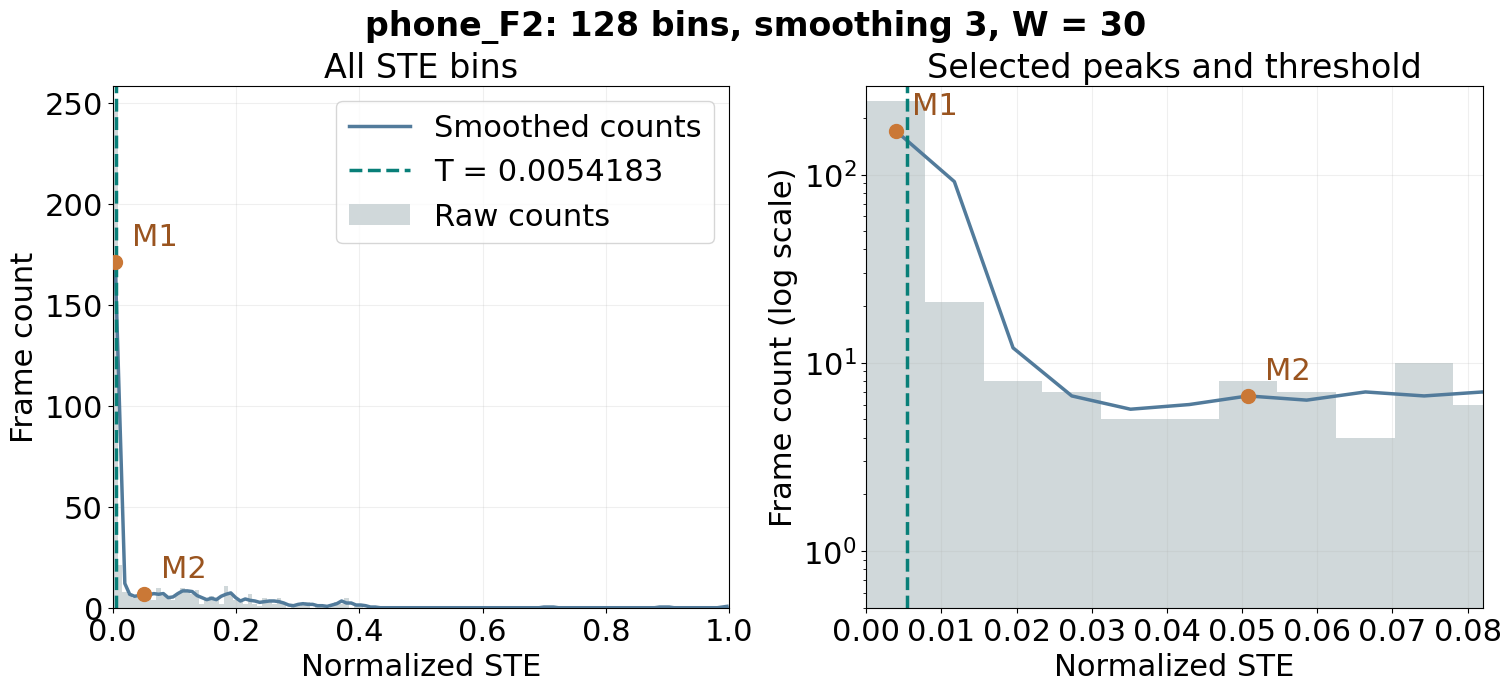

### Threshold-learning figure: histogram

Source: TEST waveform without LAB. Applied threshold T=0.0054183468.
- phone_F2: 128 bins, smoothing 3 bins, W=30 locked on TRAIN.
- First two local peaks: indices=[0, 6], bin centers=[0.00390625, 0.05078125].
- W keeps T close to M1. The two peaks need not represent pure Silence and Speech classes.


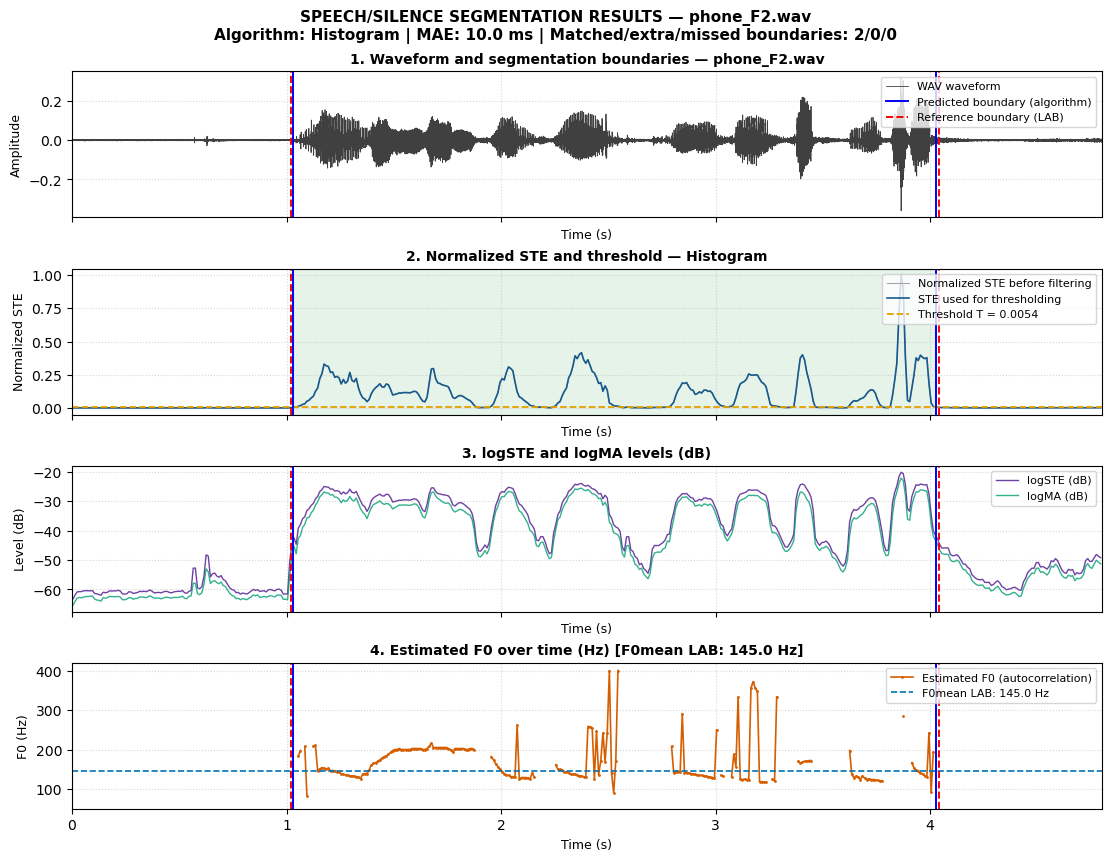

### Comments on phone_F2.wav

Fixed analysis window: 25 ms; decision hop: 10 ms.
Analysis windows are centered on 10 ms decision cells; WAV edges use actual samples.
Panels show the waveform, raw/filtered STE where applicable, threshold, boundaries, logSTE/logMA and F0.
Predicted boundaries are blue; reference boundaries are dashed red. Error units are ms.

### Histogram

Threshold 0.005418; MAE/RMSE 10.0/10.0 ms. Matched/extra/missed boundaries: 2/0/0.
- Speech onset: reference 1.02 s, predicted 1.03 s; error +10 ms.
- Speech offset: reference 4.04 s, predicted 4.03 s; error -10 ms.
- Small timing error (up to 30 ms). These categories describe the plots; they are not boundary-matching tolerances.
- Timing differences are consistent with energy rising/falling around the threshold and overlapping windows. This is an interpretation of the STE plot, not proof of a unique cause.

Estimated F0: median 148.1 Hz. Reference LAB F0mean: 145.0 Hz.
Gaps in F0 mark frames that fail the energy/correlation checks. A gap does not prove unvoiced Speech; sharp peaks may result from harmonic confusion.


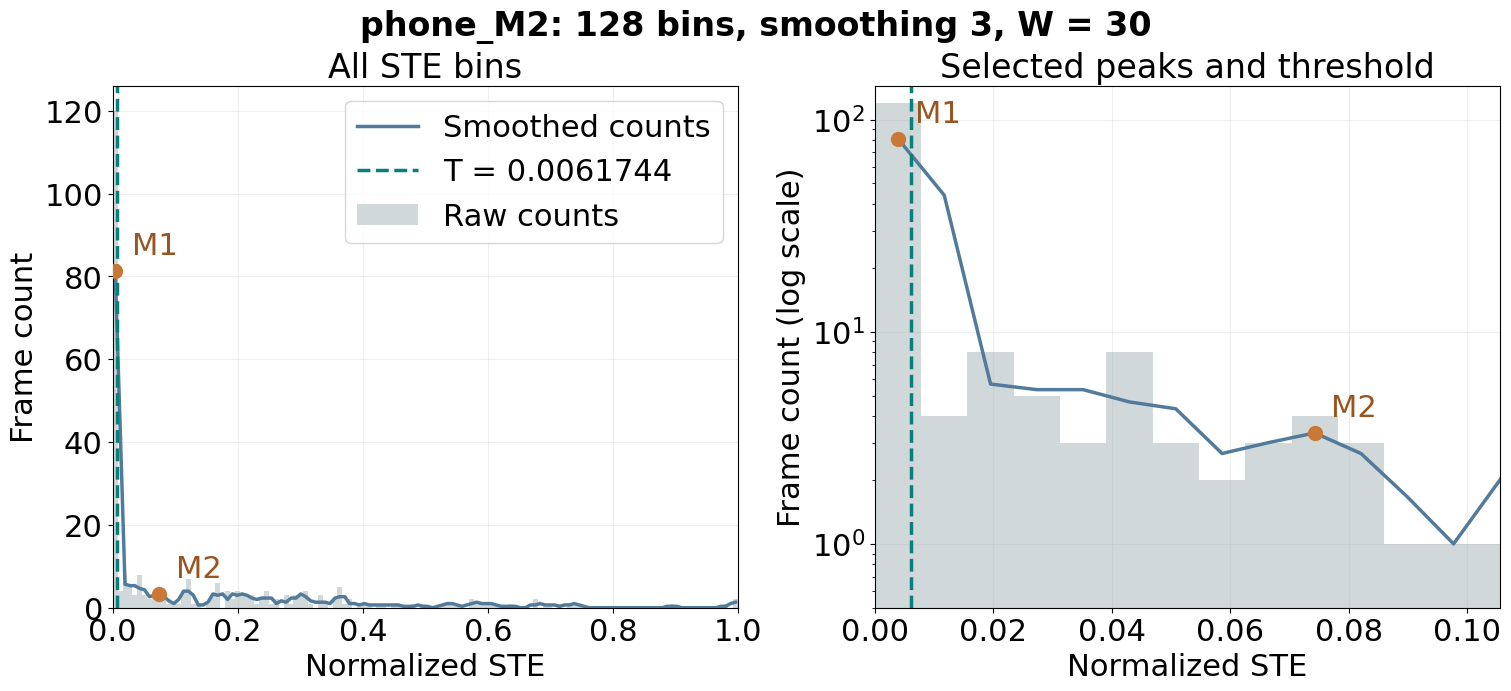

### Threshold-learning figure: histogram

Source: TEST waveform without LAB. Applied threshold T=0.0061743952.
- phone_M2: 128 bins, smoothing 3 bins, W=30 locked on TRAIN.
- First two local peaks: indices=[0, 9], bin centers=[0.00390625, 0.07421875].
- W keeps T close to M1. The two peaks need not represent pure Silence and Speech classes.


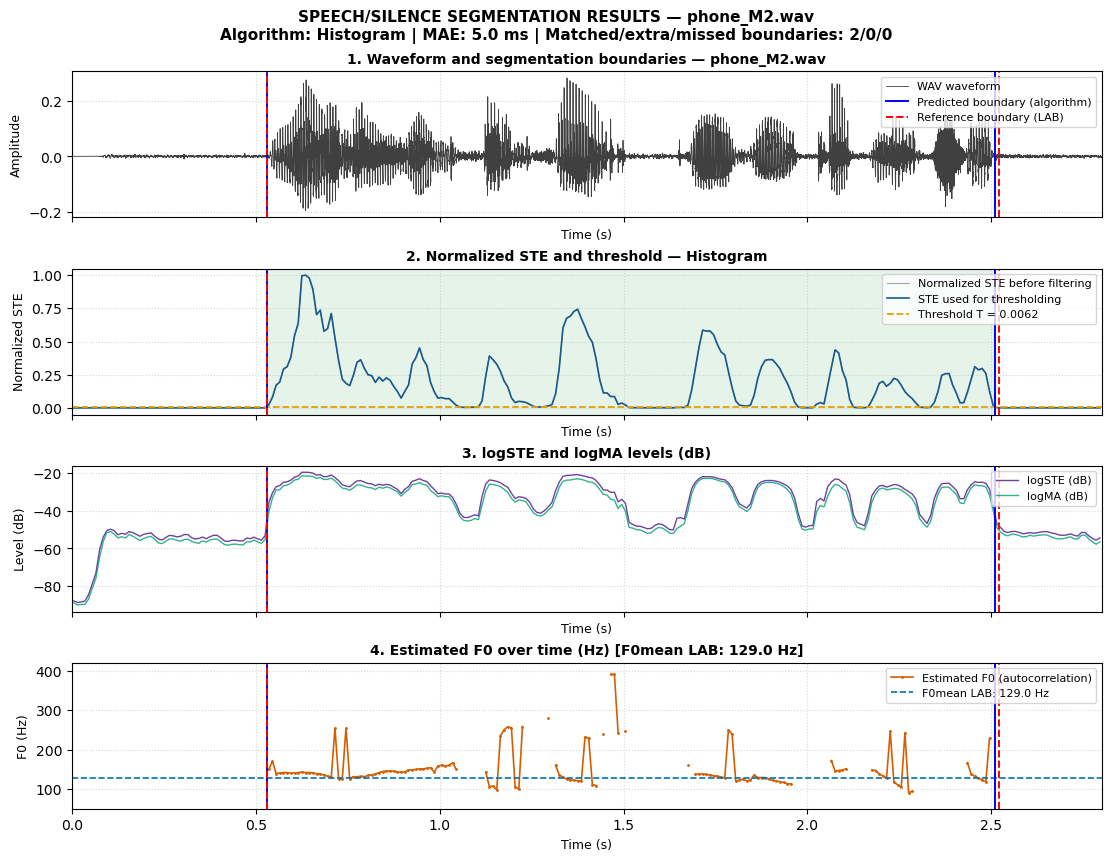

### Comments on phone_M2.wav

Fixed analysis window: 25 ms; decision hop: 10 ms.
Analysis windows are centered on 10 ms decision cells; WAV edges use actual samples.
Panels show the waveform, raw/filtered STE where applicable, threshold, boundaries, logSTE/logMA and F0.
Predicted boundaries are blue; reference boundaries are dashed red. Error units are ms.

### Histogram

Threshold 0.006174; MAE/RMSE 5.0/7.1 ms. Matched/extra/missed boundaries: 2/0/0.
- Speech onset: reference 0.53 s, predicted 0.53 s; error +0 ms.
- Speech offset: reference 2.52 s, predicted 2.51 s; error -10 ms.
- Small timing error (up to 30 ms). These categories describe the plots; they are not boundary-matching tolerances.
- Timing differences are consistent with energy rising/falling around the threshold and overlapping windows. This is an interpretation of the STE plot, not proof of a unique cause.

Estimated F0: median 139.1 Hz. Reference LAB F0mean: 129.0 Hz.
Gaps in F0 mark frames that fail the energy/correlation checks. A gap does not prove unvoiced Speech; sharp peaks may result from harmonic confusion.


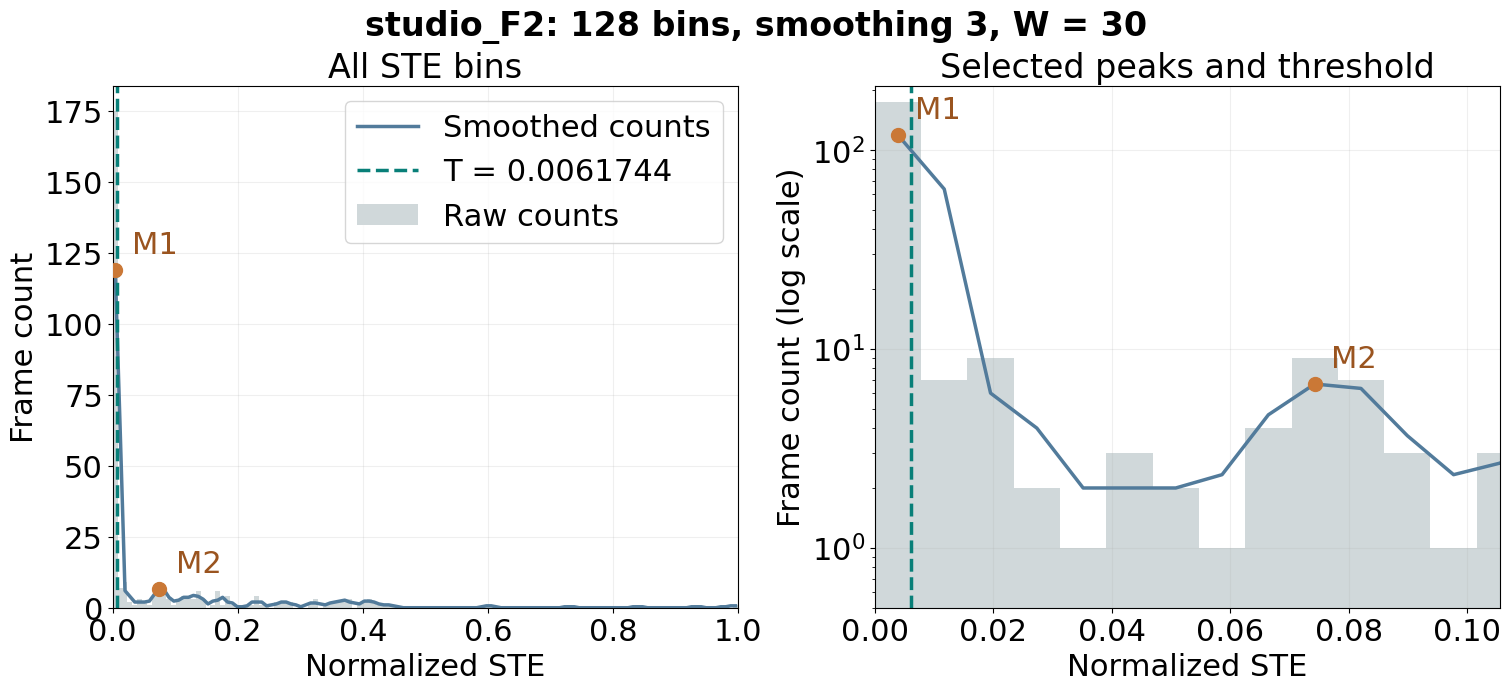

### Threshold-learning figure: histogram

Source: TEST waveform without LAB. Applied threshold T=0.0061743952.
- studio_F2: 128 bins, smoothing 3 bins, W=30 locked on TRAIN.
- First two local peaks: indices=[0, 9], bin centers=[0.00390625, 0.07421875].
- W keeps T close to M1. The two peaks need not represent pure Silence and Speech classes.


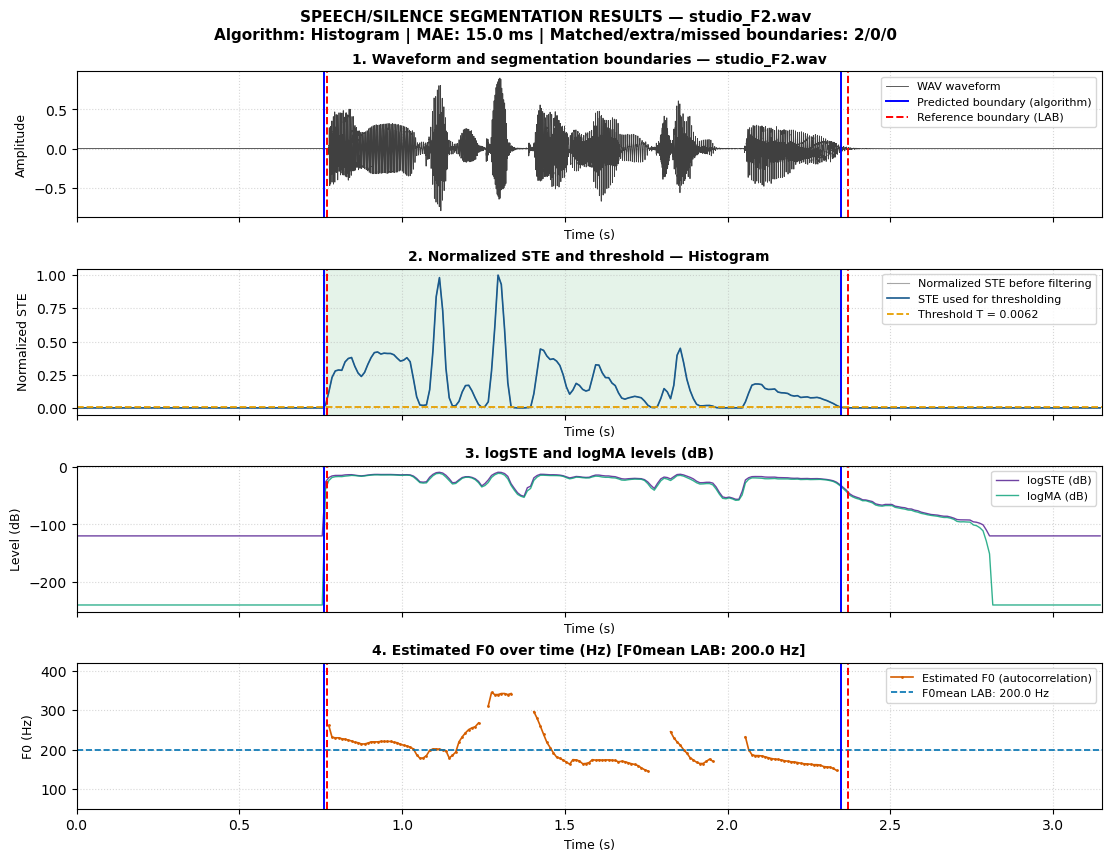

### Comments on studio_F2.wav

Fixed analysis window: 25 ms; decision hop: 10 ms.
Analysis windows are centered on 10 ms decision cells; WAV edges use actual samples.
Panels show the waveform, raw/filtered STE where applicable, threshold, boundaries, logSTE/logMA and F0.
Predicted boundaries are blue; reference boundaries are dashed red. Error units are ms.

### Histogram

Threshold 0.006174; MAE/RMSE 15.0/15.8 ms. Matched/extra/missed boundaries: 2/0/0.
- Speech onset: reference 0.77 s, predicted 0.76 s; error -10 ms.
- Speech offset: reference 2.37 s, predicted 2.35 s; error -20 ms.
- Small timing error (up to 30 ms). These categories describe the plots; they are not boundary-matching tolerances.
- Timing differences are consistent with energy rising/falling around the threshold and overlapping windows. This is an interpretation of the STE plot, not proof of a unique cause.

Estimated F0: median 184.9 Hz. Reference LAB F0mean: 200.0 Hz.
Gaps in F0 mark frames that fail the energy/correlation checks. A gap does not prove unvoiced Speech; sharp peaks may result from harmonic confusion.


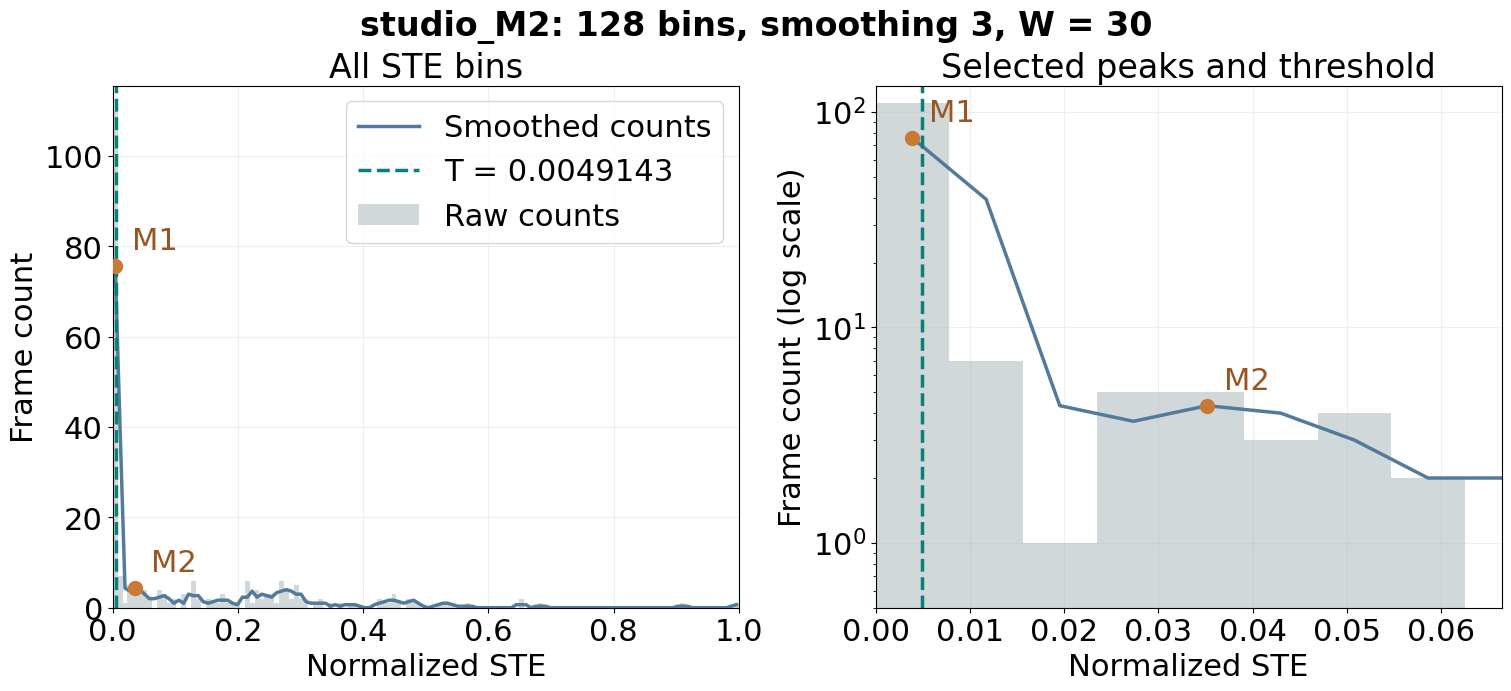

### Threshold-learning figure: histogram

Source: TEST waveform without LAB. Applied threshold T=0.0049143145.
- studio_M2: 128 bins, smoothing 3 bins, W=30 locked on TRAIN.
- First two local peaks: indices=[0, 4], bin centers=[0.00390625, 0.03515625].
- W keeps T close to M1. The two peaks need not represent pure Silence and Speech classes.


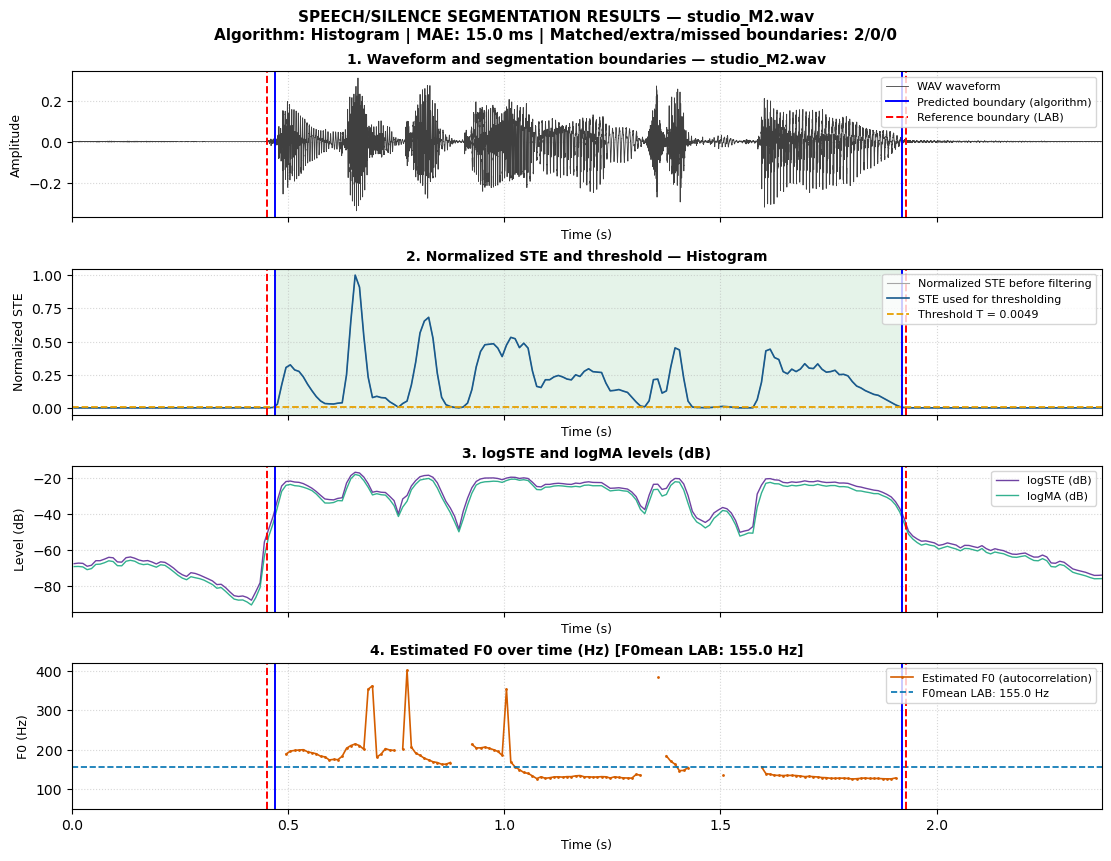

### Comments on studio_M2.wav

Fixed analysis window: 25 ms; decision hop: 10 ms.
Analysis windows are centered on 10 ms decision cells; WAV edges use actual samples.
Panels show the waveform, raw/filtered STE where applicable, threshold, boundaries, logSTE/logMA and F0.
Predicted boundaries are blue; reference boundaries are dashed red. Error units are ms.

### Histogram

Threshold 0.004914; MAE/RMSE 15.0/15.8 ms. Matched/extra/missed boundaries: 2/0/0.
- Speech onset: reference 0.45 s, predicted 0.47 s; error +20 ms.
- Speech offset: reference 1.93 s, predicted 1.92 s; error -10 ms.
- Small timing error (up to 30 ms). These categories describe the plots; they are not boundary-matching tolerances.
- Timing differences are consistent with energy rising/falling around the threshold and overlapping windows. This is an interpretation of the STE plot, not proof of a unique cause.

Estimated F0: median 140.7 Hz. Reference LAB F0mean: 155.0 Hz.
Gaps in F0 mark frames that fail the energy/correlation checks. A gap does not prove unvoiced Speech; sharp peaks may result from harmonic confusion.


### Results for all TEST recordings

| WAV | Threshold | MAE (ms) | RMSE (ms) | Matched/extra/missed | BER |
|---|---:|---:|---:|---|---:|
| phone_F2 | 0.00541835 | 10.0 | 10.0 | 2/0/0 | 0.0033 |
| phone_M2 | 0.00617440 | 5.0 | 7.1 | 2/0/0 | 0.0025 |
| studio_F2 | 0.00617440 | 15.0 | 15.8 | 2/0/0 | 0.0095 |
| studio_M2 | 0.00491431 | 15.0 | 15.8 | 2/0/0 | 0.0101 |
| **Mean across files** | | **11.3** | **12.2** | | |
| **Pooled boundaries** | | **11.3** | **12.7** | 8/0/0 | |

In [9]:
# One main call processes all four WAVs and stores the results in notebook outputs.
RESULT = main()

## 10. Noise and SNR analysis

Estimate background SNR after prediction. In the noise experiment, Q is the power ratio of the entire WAV to the added white noise; it is not a clean-speech SNR. Only transform the four existing TEST WAVs. Do not use this analysis to tune the parameters.

In [10]:
def analyze_noise(records: list[Record], model: dict) -> list[dict]:
    """Analyze added-noise BER for TEST recordings and the locked model, without retraining."""
    # Block 1: Use LAB only for background-SNR analysis after prediction, without retuning.
    lines = ["### Background SNR estimated from labeled regions", "", "| WAV | SNR (dB) |", "|---|---:|"]
    for record in records:
        value = estimate_snr(record)
        lines.append(f"| {record.name} | {value:.1f} |" if value is not None else f"| {record.name} | N/A |")
    display(Markdown("\n".join(lines)))

    # Block 2: Set white-noise power relative to the full WAV, using the three original seeds.
    summary = []
    for db in (30, 20, 10, 0):
        errors = []
        for record in records:
            power = float(np.mean(record.samples ** 2))
            for seed in (2026, 2027, 2028):
                rng = np.random.default_rng(seed)
                added = rng.normal(0, np.sqrt(power / (10 ** (db / 10))), len(record.samples))

                # Block 3: Keep thresholds and hyperparameters locked during noise analysis.
                f, mask, _, _ = predict_signal(record.samples + added, record.fs, model, compute_f0=False)
                errors.append(score(record, f, mask)["balanced_error"])
        summary.append({"signal_to_added_noise_db": db, "balanced_error": float(np.mean(errors))})
    table = ["### Added-noise analysis", "", "| Q (dB) | Mean BER |", "|---:|---:|"]
    table.extend(f'| {r["signal_to_added_noise_db"]} | {r["balanced_error"]:.3f} |' for r in summary)
    display(Markdown("\n".join(table)))
    return summary


NOISE_SUMMARY = analyze_noise(RESULT["test_records"], RESULT["model"])


### Background SNR estimated from labeled regions

| WAV | SNR (dB) |
|---|---:|
| phone_F2 | 24.8 |
| phone_M2 | 27.0 |
| studio_F2 | 49.3 |
| studio_M2 | 37.7 |

### Added-noise analysis

| Q (dB) | Mean BER |
|---:|---:|
| 30 | 0.007 |
| 20 | 0.006 |
| 10 | 0.131 |
| 0 | 0.382 |

## 11. Conclusions and limitations

Interpret MAE and RMSE together with extra and missed boundary counts. The proposed explanations for errors are interpretations of STE and post-processing, not proof of a unique cause. The dataset contains only four TEST WAVs, each with one binary Speech region, so the results do not represent every conversation or recording environment. The implementation follows the BT1 comparison report; the original BT1 source code is unavailable. The eight W candidates, replicated-edge median filtering and the additional Gaussian-root selection rule are the reconstruction defaults used here.

In [11]:
# Summarize the computed results rather than inserting fixed metric values.
p = RESULT["pooled"]
display(Markdown(f'**{METHOD_LABELS[METHOD]}**: pooled MAE **{format_metric(p["pooled_mae_ms"])} ms**, '
                 f'RMSE **{format_metric(p["pooled_rmse_ms"])} ms**; '
                 f'matched/extra/missed boundaries **{p["matched"]}/{p["extra"]}/{p["missed"]}**.'))

**Histogram**: pooled MAE **11.3 ms**, RMSE **12.7 ms**; matched/extra/missed boundaries **8/0/0**.